In [10]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
data = load_breast_cancer()
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [5]:
data.data.shape

(569, 30)

In [6]:
data.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [8]:
rfc = RandomForestClassifier(n_estimators =100 ,random_state=0)
score= cross_val_score(rfc,data.data,data.target,cv=10).mean()
score

np.float64(0.9649122807017545)

0.9666666666666666 191


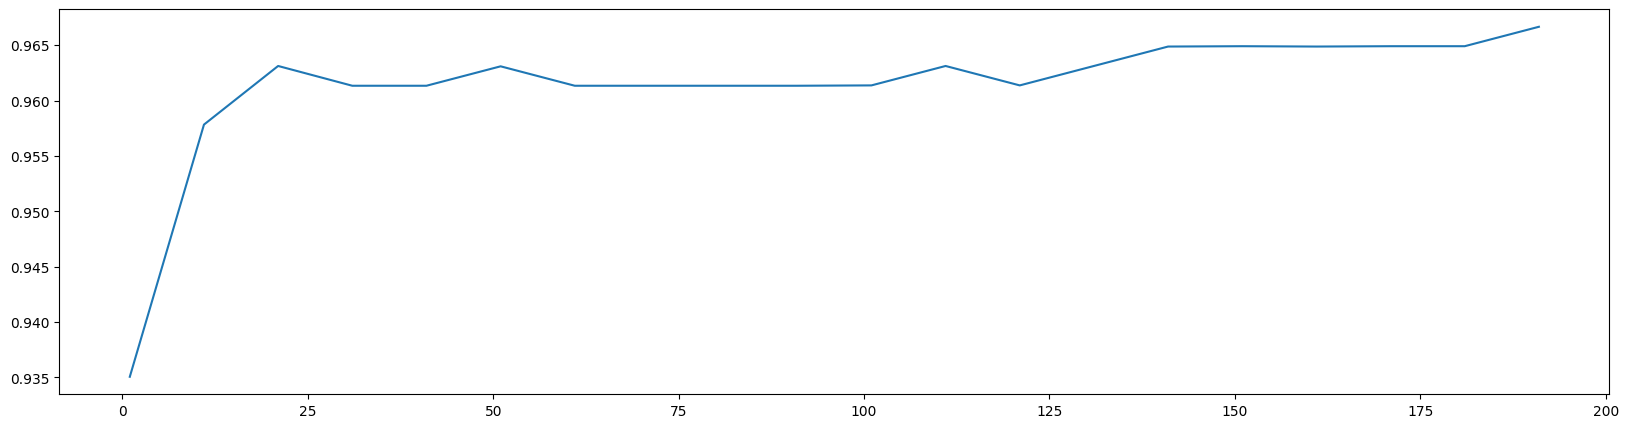

In [27]:
# Validation curce for n_estimators （vague range）
scorelist = []

for i in range(0,200,10):
    rfc = RandomForestClassifier(n_estimators = i+1,n_jobs = -1, random_state = 1)
    score = cross_val_score(rfc,data.data,data.target,cv=10).mean()
    scorelist.append(score)
print(max(scorelist),(scorelist.index(max(scorelist))*10)+1)

plt.figure(figsize=[20,5])
plt.plot(range(1,201,10),scorelist)
plt.show()

0.9666666666666666 204


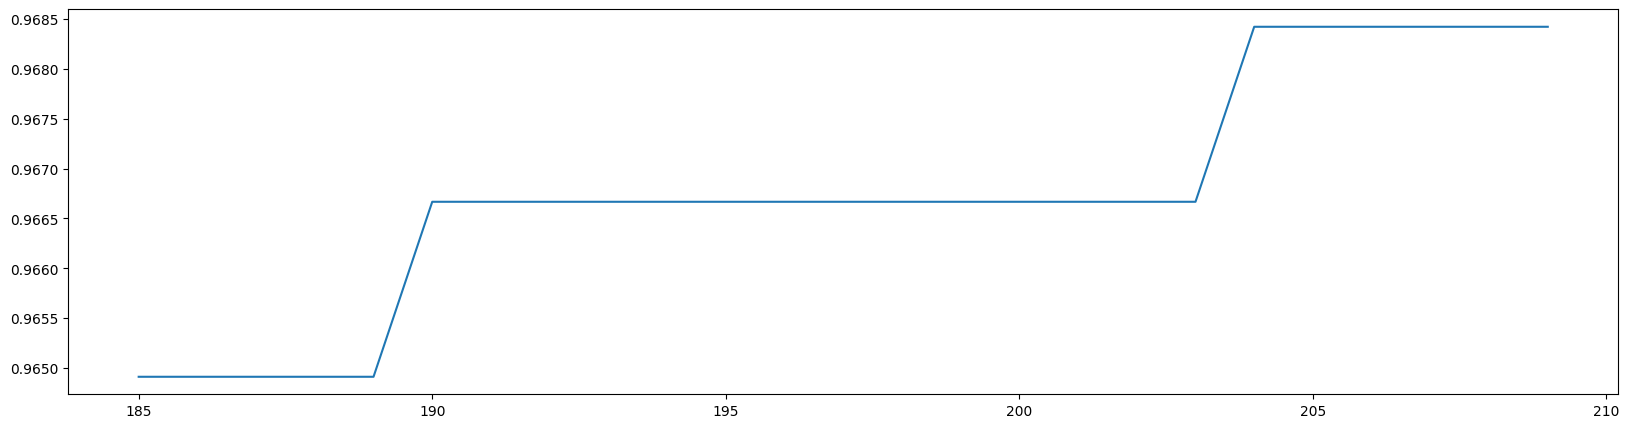

In [15]:
# A more precised validation cruve
scorelist2 = []

for i in range(185,210):
    rfc = RandomForestClassifier(n_estimators = i,n_jobs = -1, random_state = 1)
    score = cross_val_score(rfc,data.data,data.target,cv=10).mean()
    scorelist2.append(score)
    
print(max(scorelist),([*range(185,210)][scorelist2.index(max(scorelist2))]))
plt.figure(figsize=[20,5])
plt.plot(range(185,210),scorelist2)
plt.show()

In [18]:
# Grid Search for "max_depth" with "n_estimators" as 191

grid  ={'max_depth':np.arange(1,20,1)}

rfc = RandomForestClassifier(n_estimators = 191, random_state = 1)
gs = GridSearchCV(rfc,grid,cv=10)
gs.fit(data.data,data.target)


,estimator,RandomForestC...andom_state=1)
,param_grid,"{'max_depth': array([ 1, 2... 18, 19])}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,191


In [20]:
gs.best_params_

{'max_depth': np.int64(8)}

In [22]:
# As a result max_depth wouldn't increase the score so far
gs.best_score_

np.float64(0.9666666666666666)

In [23]:
# Grid Search for "max_feature" with "n_estimators" as 191 

grid  ={'max_features':np.arange(10,50,1)}

rfc = RandomForestClassifier(n_estimators = 191, random_state = 1)
gs = GridSearchCV(rfc,grid,cv=10)
gs.fit(data.data,data.target)

,estimator,RandomForestC...andom_state=1)
,param_grid,"{'max_features': array([10, 11..., 47, 48, 49])}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,191


In [24]:
gs.best_params_

{'max_features': np.int64(10)}

In [26]:
# As a result, it proves that the model already reached to its best performance, no futher adjustment required
gs.best_score_

np.float64(0.9631578947368421)